In [53]:

# -*- coding: utf-8 -*-
"""
Figura tipo "tabla" (supervisado: binaria, multiclase, regresión; no supervisado: clustering)
Compatible con Python 3.12 + scikit-learn >= 1.5 (sin usar multi_class deprecated).
"""

import numpy as np
import matplotlib.pyplot as plt
from matplotlib import gridspec
from sklearn.datasets import make_classification, make_blobs
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline
from sklearn.cluster import KMeans

np.random.seed(7)

# -----------------------------
# Datos: clasificación binaria
# -----------------------------
Xb, yb = make_classification(
    n_samples=140, n_features=2, n_redundant=0, n_informative=2,
    n_clusters_per_class=1, class_sep=1.2, random_state=2
)
clf_bin = LogisticRegression().fit(Xb, yb)

xb0_min, xb0_max = Xb[:, 0].min() - 1, Xb[:, 0].max() + 1
xb1_min, xb1_max = Xb[:, 1].min() - 1, Xb[:, 1].max() + 1
xxb, yyb = np.meshgrid(np.linspace(xb0_min, xb0_max, 250),
                       np.linspace(xb1_min, xb1_max, 250))
Zb = clf_bin.predict(np.c_[xxb.ravel(), yyb.ravel()]).reshape(xxb.shape)

# -----------------------------
# Datos: clasificación multiclase
# -----------------------------
Xm, ym = make_blobs(n_samples=180, centers=3, cluster_std=1.0, random_state=4)
clf_multi = LogisticRegression().fit(Xm, ym)

xm0_min, xm0_max = Xm[:, 0].min() - 1, Xm[:, 0].max() + 1
xm1_min, xm1_max = Xm[:, 1].min() - 1, Xm[:, 1].max() + 1
xxm, yym = np.meshgrid(np.linspace(xm0_min, xm0_max, 250),
                       np.linspace(xm1_min, xm1_max, 250))
Zm = clf_multi.predict(np.c_[xxm.ravel(), yym.ravel()]).reshape(xxm.shape)

# -----------------------------
# Datos: regresión (1D) + modelo cuadrático
# -----------------------------
n = 160
xr = np.linspace(50, 225, n)
yr = 60 - 0.35 * xr + 0.0012 * xr**2 + np.random.normal(0, 3.2, size=n)

reg_poly = make_pipeline(
    PolynomialFeatures(degree=2, include_bias=False),
    LinearRegression()
)
reg_poly.fit(xr.reshape(-1, 1), yr)
xr_grid = np.linspace(xr.min(), xr.max(), 300)
yr_pred = reg_poly.predict(xr_grid.reshape(-1, 1))

# -----------------------------
# Datos: clustering
# -----------------------------
Xc, _ = make_blobs(n_samples=250, centers=10, cluster_std=0.13, random_state=3)
km = KMeans(n_clusters=10, n_init=10, random_state=3).fit(Xc)
yc = km.labels_

# -----------------------------
# Layout tipo "tabla"
# Columnas: 0 ML | 1 sup/unsup | 2 tarea | 3 subtipo | 4 datos | 5 modelo
# -----------------------------
'''
fig = plt.figure(figsize=(16, 8.5), dpi=160)
gs = gridspec.GridSpec(
    nrows=4, ncols=6, figure=fig,
    width_ratios=[1.2, 2.0, 1.8, 1.6, 2.4, 2.4],
    height_ratios=[1.0, 1.0, 1.0, 1.0],
    wspace=0.0, hspace=0.0
)'''

def boxed_text_ax(r0, r1, c0, c1, text, fontsize=11, weight="bold", style=None):
    ax = fig.add_subplot(gs[r0:r1, c0:c1])
    ax.set_xticks([]); ax.set_yticks([])
    for sp in ax.spines.values():
        sp.set_visible(True)
    ax.set_facecolor("white")
    ax.text(0.5, 0.5, text, ha="center", va="center",
            fontsize=fontsize, fontweight=weight, style=style)
    return ax

def style_plot_ax(ax):
    for sp in ax.spines.values():
        sp.set_visible(True)
    ax.tick_params(labelsize=8)

def plot_scatter_labeled(ax, X, y, title):
    ax.set_title(title, fontsize=11, pad=1)
    ax.scatter(X[:, 0], X[:, 1], c=y, s=14, edgecolors="k", linewidths=0.2)
    style_plot_ax(ax)

def plot_regions(ax, xx, yy, Z, X, y, title):
    ax.set_title(title, fontsize=11, pad=1)
    ax.contourf(xx, yy, Z, alpha=0.45)
    ax.scatter(X[:, 0], X[:, 1], c=y, s=14, edgecolors="k", linewidths=0.2)
    style_plot_ax(ax)

def plot_reg(ax, x, y, title):
    ax.set_title(title, fontsize=11, pad=1)
    ax.scatter(x, y, s=10, edgecolors="k", linewidths=0.15)
    style_plot_ax(ax)

def plot_reg_model(ax, x, y, xg, yg, title):
    ax.set_title(title, fontsize=11, pad=1)
    ax.scatter(x, y, s=10, edgecolors="k", linewidths=0.15)
    ax.plot(xg, yg, linewidth=2.0)
    style_plot_ax(ax)

# Col 4-5: plots por fila
fig = plt.figure(figsize=(16, 8.5), dpi=160)
ax_bin_data = fig.add_subplot(gs[0, 4]); plot_scatter_labeled(ax_bin_data, Xb, yb, "Datos etiquetados")
fig.savefig("binaria_etiquetados.png", dpi=300, bbox_inches="tight", pad_inches=0.02)
plt.close(fig) 

fig = plt.figure(figsize=(16, 8.5), dpi=160)
ax_bin_mod  = fig.add_subplot(gs[0, 5]); plot_regions(ax_bin_mod, xxb, yyb, Zb, Xb, yb, "Modelo")
fig.savefig("binaria_modelo.png", dpi=300, bbox_inches="tight", pad_inches=0.02)
plt.close(fig) 

fig = plt.figure(figsize=(16, 8.5), dpi=160)
ax_mul_data = fig.add_subplot(gs[1, 4]); plot_scatter_labeled(ax_mul_data, Xm, ym, "Datos etiquetados")
fig.savefig("multi_etiquetados.png", dpi=300, bbox_inches="tight", pad_inches=0.02)
plt.close(fig) 

fig = plt.figure(figsize=(16, 8.5), dpi=160)
ax_mul_mod  = fig.add_subplot(gs[1, 5]); plot_regions(ax_mul_mod, xxm, yym, Zm, Xm, ym, "Modelo")
fig.savefig("multi_modelo.png", dpi=300, bbox_inches="tight", pad_inches=0.02)
plt.close(fig) 

fig = plt.figure(figsize=(16, 8.5), dpi=160)
ax_reg_data = fig.add_subplot(gs[2, 4]); plot_reg(ax_reg_data, xr, yr, "Datos etiquetados")
fig.savefig("regresion_etiquetados.png", dpi=300, bbox_inches="tight", pad_inches=0.02)
plt.close(fig) 

fig = plt.figure(figsize=(16, 8.5), dpi=160)
ax_reg_mod  = fig.add_subplot(gs[2, 5]); plot_reg_model(ax_reg_mod, xr, yr, xr_grid, yr_pred, "Modelo")
fig.savefig("regresion_modelo.png", dpi=300, bbox_inches="tight", pad_inches=0.02)
plt.close(fig) 

fig = plt.figure(figsize=(16, 8.5), dpi=160)
ax_clu_data = fig.add_subplot(gs[3, 4]); ax_clu_data.set_title("Datos no etiquetados", fontsize=11, pad=6)
ax_clu_data.scatter(Xc[:, 0], Xc[:, 1], s=10, edgecolors="k", linewidths=0.15)
style_plot_ax(ax_clu_data)
fig.savefig("clustering_no_etiquetados.png", dpi=300, bbox_inches="tight", pad_inches=0.02)
plt.close(fig) 

fig = plt.figure(figsize=(16, 8.5), dpi=160)
ax_clu_mod = fig.add_subplot(gs[3, 5])
ax_clu_mod.set_title("Datos semi etiquetados", fontsize=11, pad=6)
ax_clu_mod.scatter(Xc[:, 0], Xc[:, 1], c=yc, s=10, edgecolors="k", linewidths=0.15)
style_plot_ax(ax_clu_mod)
fig.savefig("clustering_etiquetados.png", dpi=300, bbox_inches="tight", pad_inches=0.02)
plt.close(fig) 





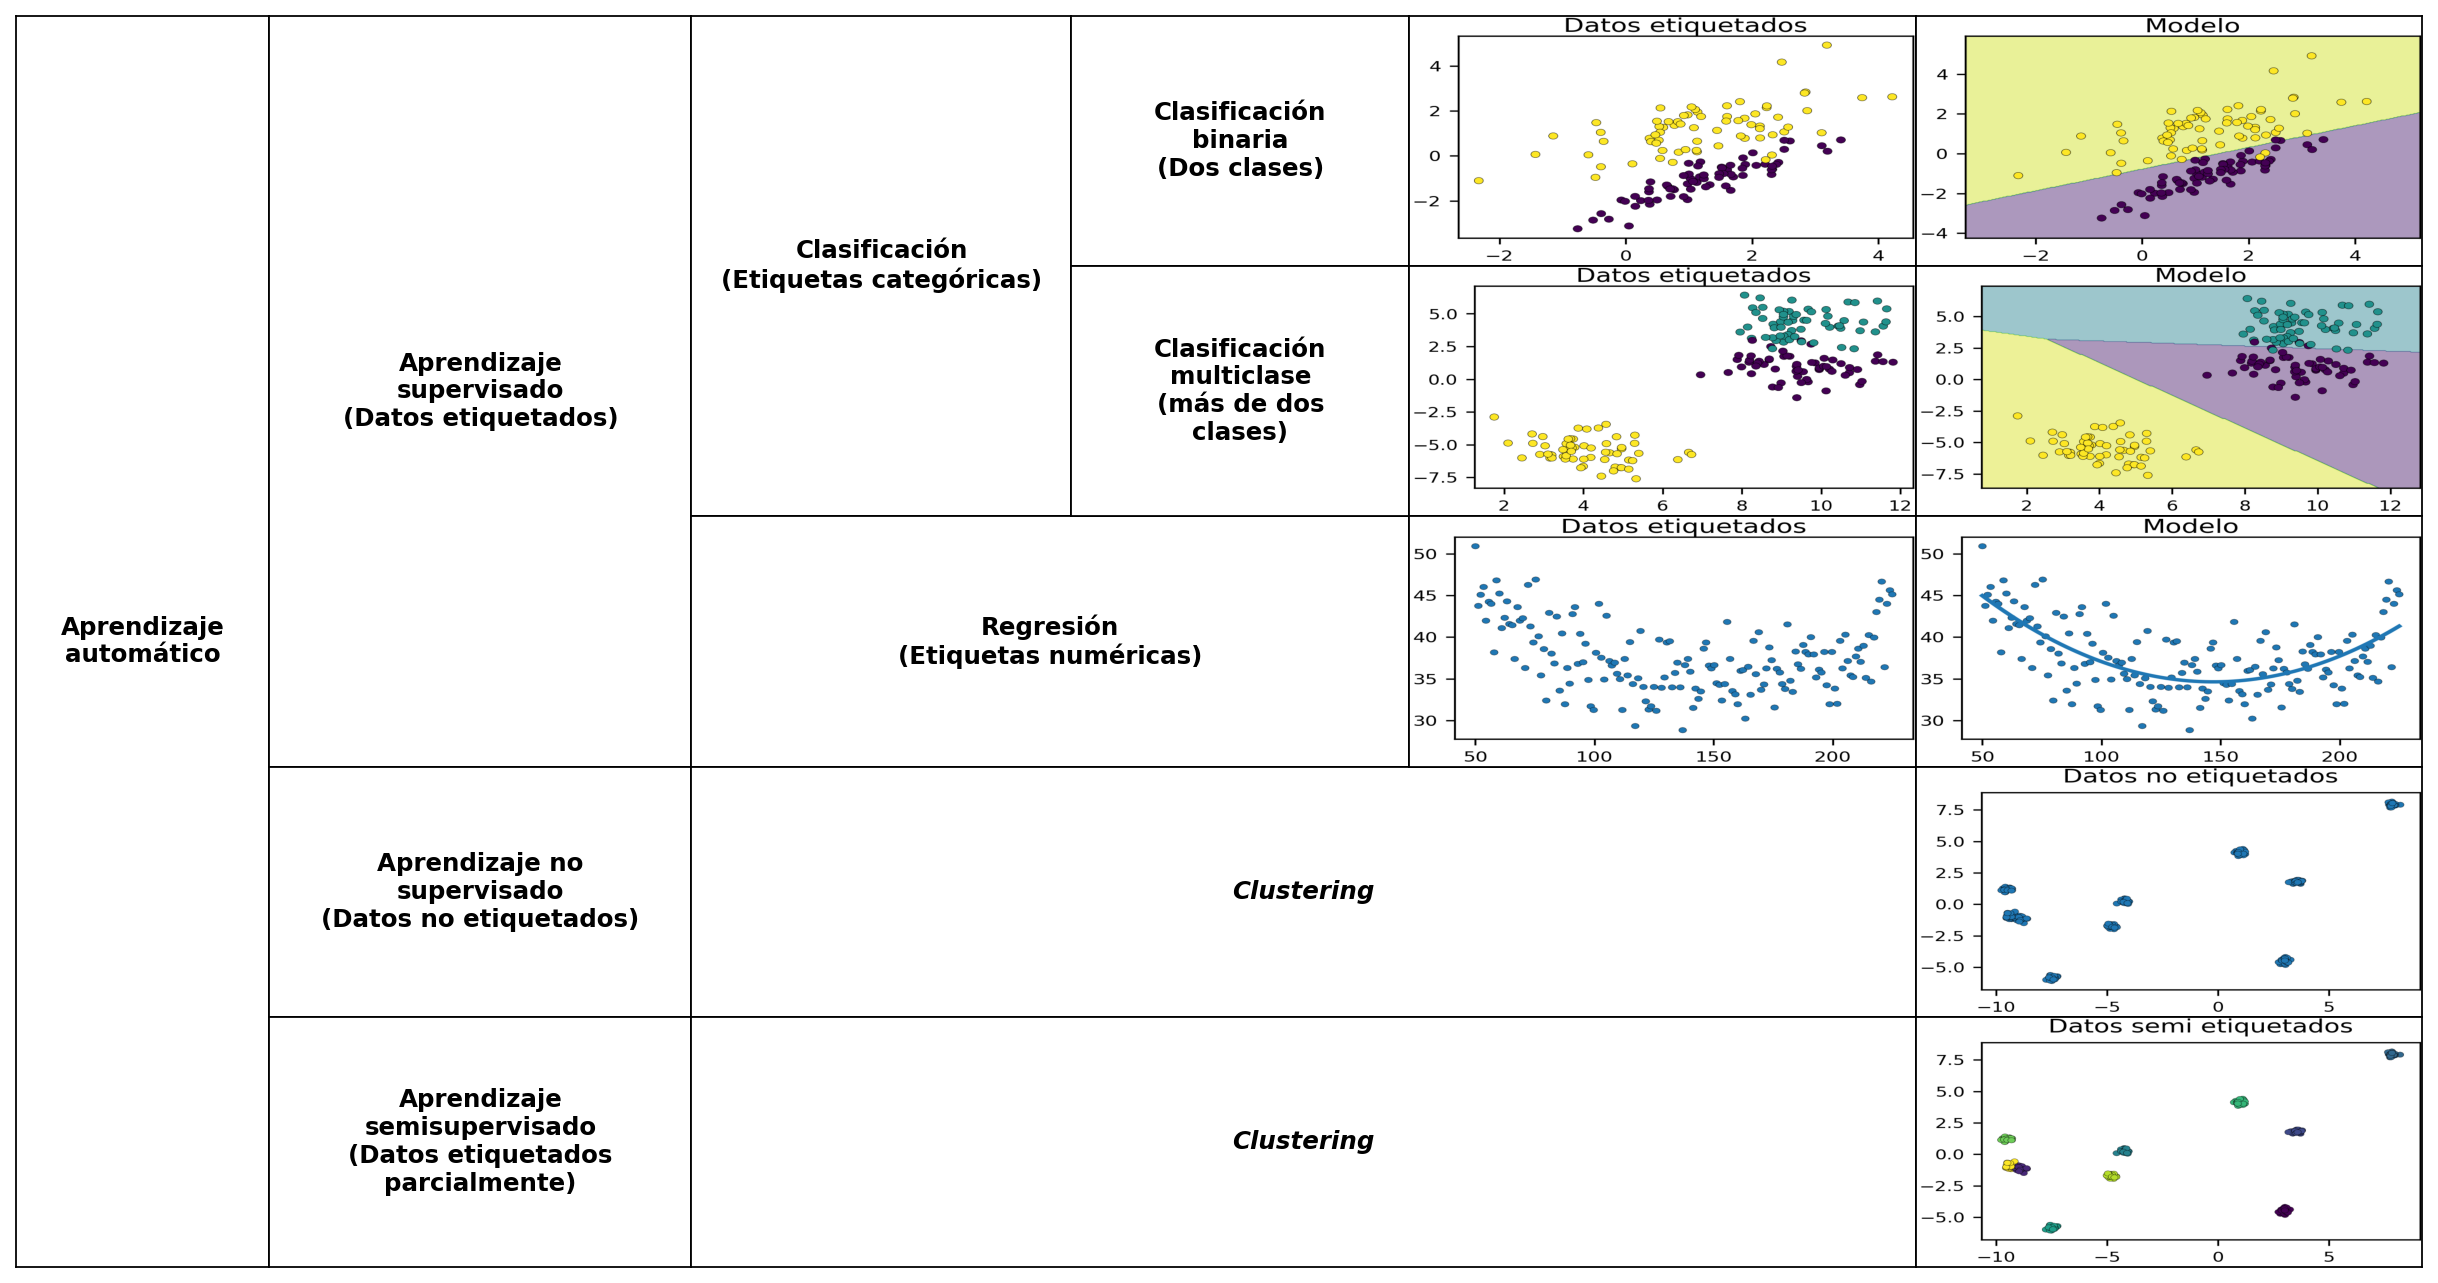

Guardado como: tabla_aprendizaje_automatico.png


In [57]:
import matplotlib.pyplot as plt
from matplotlib import gridspec
import matplotlib.image as mpimg


# -----------------------------
# Layout tipo "tabla"
# Columnas: 0 ML | 1 sup/unsup | 2 tarea | 3 subtipo | 4 datos | 5 modelo
# -----------------------------
fig = plt.figure(figsize=(16, 8.5), dpi=160)
gs = gridspec.GridSpec(
    nrows=5, ncols=6, figure=fig,
    width_ratios=[1.2, 2.0, 1.8, 1.6, 2.4, 2.4],
    height_ratios=[1.0, 1.0, 1.0, 1.0, 1.0],
    wspace=0.0, hspace=0.0
)

# Col 0: Aprendizaje automático (toda la altura)
boxed_text_ax(0, 5, 0, 1, "Aprendizaje\nautomático", fontsize=11)

# Col 1: supervisado (filas 0-2) / no supervisado (fila 3)
boxed_text_ax(0, 3, 1, 2, "Aprendizaje\nsupervisado\n(Datos etiquetados)", fontsize=11)
boxed_text_ax(3, 4, 1, 2, "Aprendizaje no\nsupervisado\n(Datos no etiquetados)", fontsize=11)
boxed_text_ax(4, 5, 1, 2, "Aprendizaje\nsemisupervisado\n(Datos etiquetados\nparcialmente)", fontsize=11)

# Col 2: tareas
boxed_text_ax(0, 2, 2, 3, "Clasificación\n(Etiquetas categóricas)", fontsize=11)
boxed_text_ax(2, 3, 2, 4, "Regresión\n(Etiquetas numéricas)", fontsize=11)
boxed_text_ax(3, 4, 2, 5, "Clustering", fontsize=11, style="italic")
boxed_text_ax(4, 5, 2, 5, "Clustering", fontsize=11, style="italic")

# Col 3: subtipos
boxed_text_ax(0, 1, 3, 4, "Clasificación\nbinaria\n(Dos clases)", fontsize=11)
boxed_text_ax(1, 2, 3, 4, "Clasificación\nmulticlase\n(más de dos\nclases)", fontsize=11)

# Col 4 y 5: subtipos
boxed_text_ax(0, 1, 4, 5,"", fontsize=11).imshow(mpimg.imread("binaria_etiquetados.png"),aspect="auto")
boxed_text_ax(0, 1, 5, 6,"", fontsize=11).imshow(mpimg.imread("binaria_modelo.png"),aspect="auto")
boxed_text_ax(1, 2, 4, 5, "", fontsize=11).imshow(mpimg.imread("multi_etiquetados.png"),aspect="auto")
boxed_text_ax(1, 2, 5, 6, "", fontsize=11).imshow(mpimg.imread("multi_modelo.png"),aspect="auto")
boxed_text_ax(2, 3, 4, 5, "", fontsize=11).imshow(mpimg.imread("regresion_etiquetados.png"),aspect="auto")
boxed_text_ax(2, 3, 5, 6, "", fontsize=11).imshow(mpimg.imread("regresion_modelo.png"),aspect="auto")
boxed_text_ax(3, 4, 5, 6, "", fontsize=11).imshow(mpimg.imread("clustering_no_etiquetados.png"),aspect="auto")
boxed_text_ax(4, 5, 5, 6, "", fontsize=11).imshow(mpimg.imread("clustering_etiquetados.png"),aspect="auto")


out = "tabla_aprendizaje_automatico.png"
plt.savefig(out, bbox_inches="tight")
plt.subplots_adjust(
    top=0.96,
    bottom=0.04,
    left=0.04,
    right=0.98
)

plt.show()
print(f"Guardado como: {out}")

### Método genético.. 
Intentando obtener el máximo de $$f(x)=x*sin(x)$$

Al aplicar la función de aptitud obtenemos:
población:  (1.2, 2.8, 4.5, 6.1, 8.7)
fitness:  [ 1.1184469   0.93796682 -4.39888553 -1.11119128  5.7678323 ]


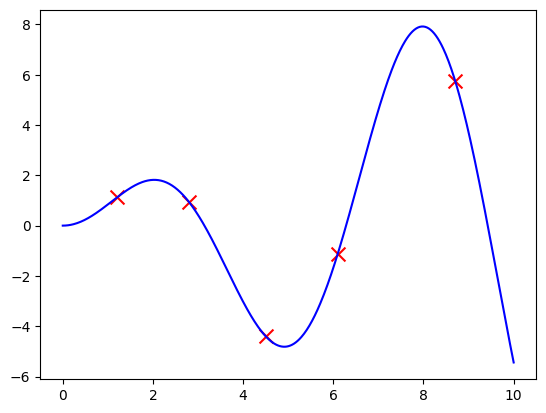

In [18]:
import numpy as np
import matplotlib.pyplot as plt
from functools import reduce
import operator


#Población con 5 puntos
p=(1.2,2.8,4.5,6.1,8.7)

#función de aptitud...
fitness = p * np.sin(p)

print('Al aplicar la función de aptitud obtenemos:')
print('población: ',p)
print('fitness: ',fitness)

#LA función de verdad:
x = np.linspace(0, 10, 500)
y = x * np.sin(x)

plt.plot(x, y, c='blue')
plt.scatter(p, fitness,c='red', marker='x', s=100)



plt.show()


     

Para evitar números negativos se suele normalizar o desplazar la función fitness. No lo vamos a hacer en este caso.

Para generar nuevos individuos de la población se usan los métodos de cruces y mutaciones. 
Los algoritmos genéticos modelan artificialmente estos procesos biológicos:
* Genes: variables de decisión
* Cromosoma: solución completa
* Cruce (crossover): recombinación genética
* Mutación (mutation): cambios aleatorios heredables
* Selección natural: supervivencia de los más aptos

Por eso se llaman genéticos: la dinámica del algoritmo imita un sistema genético


Cruces.. 

poblacion: [1.2, 2.8, 4.5, 6.1, 8.7, 1.776917122467386, 2.223082877532614, 4.417464507765199, 1.282535492234801, 4.752356339991315, 2.547643660008684, 7.025919463883828, 2.8740805361161703, 3.2479989359211787, 4.052001064078821, 3.8668916915043923, 5.033108308495607, 3.4361405505414115, 8.063859449458587, 5.9608978677929345, 4.639102132207065, 6.927928357321864, 6.272071642678135, 8.622527229461017, 6.177472770538983]
poblacion: [1.1567729011266215, 1.2, 1.282535492234801, 1.776917122467386, 2.223082877532614, 2.547643660008684, 2.748128919900544, 2.8, 2.8740805361161703, 3.2479989359211787, 3.4361405505414115, 3.8668916915043923, 4.052001064078821, 4.417464507765199, 4.4666052415297015, 4.5, 4.639102132207065, 4.752356339991315, 5.033108308495607, 5.9608978677929345, 6.1, 6.177472770538983, 6.272071642678135, 6.310595117529658, 6.927928357321864, 7.025919463883828, 8.063859449458587, 8.622527229461017, 8.661723514865134, 8.7]
Al aplicar la función de aptitud obtenemos:
población:  [1.

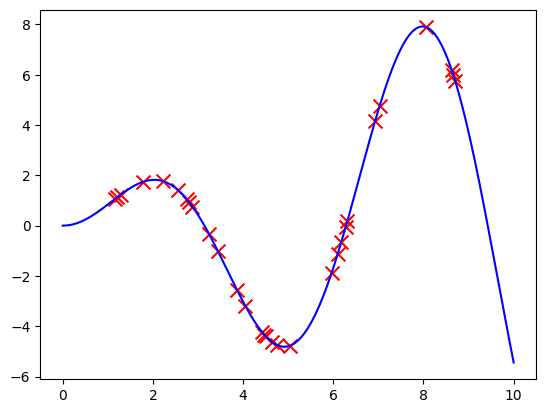

In [30]:
import random
from typing import List

def add_all_arithmetic_crossovers(p: List[float], seed: int | None = None) -> None:
    """
    Añade a p TODOS los hijos del cruce aritmético entre todos los pares (i<j).
    Por cada par (xi, xj) se generan 2 hijos con alpha aleatorio.
    Modifica p in-place.
    """
    rng = random.Random(seed)
    parents = p.copy()  # snapshot: evita usar hijos como padres

    n = len(parents)
    for i in range(n):
        for j in range(i + 1, n):
            alpha = rng.random()
            xi, xj = parents[i], parents[j]

            c1 = alpha * xi + (1.0 - alpha) * xj
            c2 = alpha * xj + (1.0 - alpha) * xi

            p.append(c1)
            p.append(c2)


# --- Ejemplo ---
p = [1.2, 2.8, 4.5, 6.1, 8.7]
add_all_arithmetic_crossovers(p, seed=42)
print("poblacion:", p)  # 25 = 5 padres + 20 hijos


#  los mutantes...

rng = random.Random(42)   # quita esto si no quieres reproducibilidad
sigma = 0.3

# p = [padres + hijos]  (ya la tienes del cruce)
# los padres son los 5 primeros
n_parents = 5

for i in range(n_parents):
    epsilon = rng.gauss(0.0, sigma)   # ε ~ N(0, σ^2)
    p.append(p[i] + epsilon)

# ordenar
p = sorted(p)

# quitar duplicados
p = list(dict.fromkeys(p))   # preserva orden tras el sorted

# filtrar intervalo (0, 10)
p = [x for x in p if 0.0 < x < 10.0]

print("poblacion:", p)

#función de aptitud...
fitness = p * np.sin(p)

print('Al aplicar la función de aptitud obtenemos:')
print('población: ',p)
print('fitness: ',fitness)

#LA función de verdad:
x = np.linspace(0, 10, 500)
y = x * np.sin(x)

plt.plot(x, y, c='blue')
plt.scatter(p, fitness,c='red', marker='x', s=100)

# Mínimos cuadrados 
Ahora vamos con una regresión por mínimos cuadrados pero en el espacio..

In [31]:
import numpy as np

# -----------------------------
# 1) Dataset sintético en R^3
#    (x1, x2, x3) -> y
# -----------------------------
rng = np.random.default_rng(42)
n = 30

X = rng.uniform(-5, 5, size=(n, 3))          # puntos en 3D
x1, x2, x3 = X[:, 0], X[:, 1], X[:, 2]

# "Hiperplano real" (desconocido para OLS)
beta0_true = 2.0
beta_true = np.array([1.5, -0.7, 0.3])       # coeficientes de x1, x2, x3
noise = rng.normal(0, 0.8, size=n)           # ruido

y = beta0_true + X @ beta_true + noise       # y = b0 + b1*x1 + b2*x2 + b3*x3 + ruido

# -----------------------------
# 2) OLS por ecuación normal
#    beta_hat = (X'X)^(-1) X'y
#    (incluimos intercepto)
# -----------------------------
X_design = np.column_stack([np.ones(n), X])  # [1, x1, x2, x3]
beta_hat = np.linalg.inv(X_design.T @ X_design) @ (X_design.T @ y)

b0_hat, b1_hat, b2_hat, b3_hat = beta_hat

print("Coeficientes estimados (OLS):")
print(f"b0 = {b0_hat:.4f}")
print(f"b1 = {b1_hat:.4f}")
print(f"b2 = {b2_hat:.4f}")
print(f"b3 = {b3_hat:.4f}")

# -----------------------------
# 3) Hiperplano resultante
#    y = b0 + b1*x1 + b2*x2 + b3*x3
# -----------------------------
print("\nHiperplano estimado:")
print(f"y = ({b0_hat:.4f}) + ({b1_hat:.4f}) x1 + ({b2_hat:.4f}) x2 + ({b3_hat:.4f}) x3")

# -----------------------------
# 4) Calidad del ajuste (R^2)
# -----------------------------
y_pred = X_design @ beta_hat
ss_res = np.sum((y - y_pred) ** 2)
ss_tot = np.sum((y - y.mean()) ** 2)
r2 = 1 - ss_res / ss_tot
print(f"\nR^2 = {r2:.4f}")


Coeficientes estimados (OLS):
b0 = 1.7553
b1 = 1.5252
b2 = -0.7221
b3 = 0.2948

Hiperplano estimado:
y = (1.7553) + (1.5252) x1 + (-0.7221) x2 + (0.2948) x3

R^2 = 0.9786


Hiperplano OLS:
y = 1.875 + 1.233 x1 + -0.849 x2 + 0.415 x3


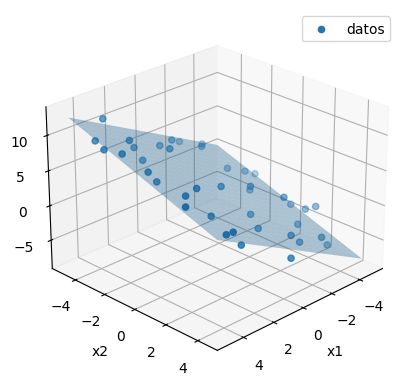

In [32]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # activa proyección 3D

# -----------------------------
# 1) Datos en 3D
# -----------------------------
rng = np.random.default_rng(1)
n = 40
X = rng.uniform(-5, 5, size=(n, 3))
x1, x2, x3 = X[:, 0], X[:, 1], X[:, 2]

# hiperplano real para generar y
b0_true = 2.0
b_true = np.array([1.2, -0.8, 0.5])
y = b0_true + X @ b_true + rng.normal(0, 0.8, size=n)

# -----------------------------
# 2) OLS (mínimos cuadrados)
# -----------------------------
X_design = np.column_stack([np.ones(n), X])
beta = np.linalg.inv(X_design.T @ X_design) @ (X_design.T @ y)
b0, b1, b2, b3 = beta

print("Hiperplano OLS:")
print(f"y = {b0:.3f} + {b1:.3f} x1 + {b2:.3f} x2 + {b3:.3f} x3")

# -----------------------------
# 3) Superficie a dibujar
# (sección del hiperplano fijando x3 = media)
# -----------------------------
x3_fixed = x3.mean()

gx1 = np.linspace(x1.min(), x1.max(), 25)
gx2 = np.linspace(x2.min(), x2.max(), 25)
GX1, GX2 = np.meshgrid(gx1, gx2)
GY = b0 + b1*GX1 + b2*GX2 + b3*x3_fixed

# -----------------------------
# 4) Plot con matplotlib
# -----------------------------
fig = plt.figure()
ax = fig.add_subplot(111, projection="3d")

# puntos
ax.scatter(x1, x2, y, label="datos")

# plano-sección
ax.plot_surface(GX1, GX2, GY, alpha=0.35)

ax.set_xlabel("x1")
ax.set_ylabel("x2")
ax.set_zlabel("y")

# vista tipo isométrica aproximada
ax.view_init(elev=25, azim=45)

plt.legend()
plt.show()


Hiperplano OLS: y = 1.875 + 1.233 x1 + -0.849 x2 + 0.415 x3


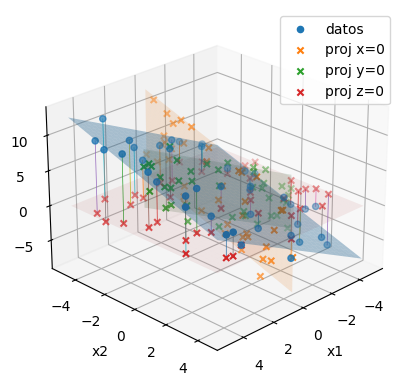

In [33]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # activa 3D

# -----------------------------
# 1) Datos en 3D
# -----------------------------
rng = np.random.default_rng(1)
n = 40
X = rng.uniform(-5, 5, size=(n, 3))
x1, x2, x3 = X[:, 0], X[:, 1], X[:, 2]

b0_true = 2.0
b_true = np.array([1.2, -0.8, 0.5])
y = b0_true + X @ b_true + rng.normal(0, 0.8, size=n)

# -----------------------------
# 2) OLS (mínimos cuadrados)
# -----------------------------
X_design = np.column_stack([np.ones(n), X])
beta = np.linalg.inv(X_design.T @ X_design) @ (X_design.T @ y)
b0, b1, b2, b3 = beta

print(f"Hiperplano OLS: y = {b0:.3f} + {b1:.3f} x1 + {b2:.3f} x2 + {b3:.3f} x3")

# -----------------------------
# 3) Malla del plano (sección x3 = media)
# -----------------------------
x3_fixed = x3.mean()
gx1 = np.linspace(x1.min(), x1.max(), 30)
gx2 = np.linspace(x2.min(), x2.max(), 30)
GX1, GX2 = np.meshgrid(gx1, gx2)
GY = b0 + b1*GX1 + b2*GX2 + b3*x3_fixed

# -----------------------------
# 4) Plot
# -----------------------------
fig = plt.figure()
ax = fig.add_subplot(111, projection="3d")

# --- puntos originales
ax.scatter(x1, x2, y, label="datos")

# --- plano OLS (sección)
ax.plot_surface(GX1, GX2, GY, alpha=0.35)

# -----------------------------
# 5) Proyecciones de puntos
# -----------------------------
# plano x=0  -> (0, x2, y)
ax.scatter(np.zeros_like(x1), x2, y, marker="x", label="proj x=0")

# plano y=0  -> (x1, 0, y)
ax.scatter(x1, np.zeros_like(x2), y, marker="x", label="proj y=0")

# plano z=0  -> aquí z ≡ y en el dibujo -> (x1, x2, 0)
ax.scatter(x1, x2, np.zeros_like(y), marker="x", label="proj z=0")

# líneas de caída (verticales a z=0)
for xi, yi, zi in zip(x1, x2, y):
    ax.plot([xi, xi], [yi, yi], [0, zi], linewidth=0.5)

# -----------------------------
# 6) Proyecciones del plano
# -----------------------------
# sobre x=0
ax.plot_surface(
    np.zeros_like(GX1),  # x=0
    GX2,
    GY,
    alpha=0.15
)

# sobre y=0
ax.plot_surface(
    GX1,
    np.zeros_like(GX2),  # y=0
    GY,
    alpha=0.15
)

# sobre z=0
ax.plot_surface(
    GX1,
    GX2,
    np.zeros_like(GY),   # z=0
    alpha=0.08
)

# -----------------------------
# 7) Estética
# -----------------------------
ax.set_xlabel("x1")
ax.set_ylabel("x2")
ax.set_zlabel("y")

ax.view_init(elev=25, azim=45)  # vista tipo isométrica aprox
ax.legend()

plt.show()
